Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")
sns.set_palette("Set2")

Load data

In [3]:
path = '/content/drive/MyDrive/olist_powerbi_data/'

rfm        = pd.read_csv(path + 'rfm_segments.csv')
delivery   = pd.read_csv(path + 'delivery_analysis.csv', decimal=',')
orders     = pd.read_csv(path + 'orders_main.csv')

print(f"rfm: {rfm.shape}")
print(f"delivery: {delivery.shape}")
print(f"orders: {orders.shape}")
print("\nRFM sample:")
print(rfm.head(3))

rfm: (96478, 5)
delivery: (96478, 6)
orders: (100757, 20)

RFM sample:
                        customer_id  recency  frequency monetary segment
0  00012a2ce6f8dcda20d059ce98491703      338          1   114,74    Lost
1  000161a058600d5901f007fab4c27140      459          1    67,41    Lost
2  0001fd6190edaaf884bcaf3d49edf079      597          1   195,42    Lost


Chuẩn bị data & Elbow method

In [6]:
# Convert monetary từ string về float
rfm['monetary'] = rfm['monetary'].astype(str).str.replace(',', '.').astype(float)

# Kiểm tra
print(rfm[['recency','frequency','monetary']].dtypes)
print(rfm['monetary'].head())

# Lấy 3 features R, F, M
X_rfm = rfm[['recency', 'frequency', 'monetary']].copy()

# Chuẩn hóa về cùng scale (quan trọng với K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

print("Trước chuẩn hóa:")
print(X_rfm.describe().round(2))
print("\nSau chuẩn hóa (mean ≈ 0, std ≈ 1):")
print(pd.DataFrame(X_scaled, columns=['recency','frequency','monetary']).describe().round(2))

recency        int64
frequency      int64
monetary     float64
dtype: object
0    114.74
1     67.41
2    195.42
3    179.35
4    107.01
Name: monetary, dtype: float64
Trước chuẩn hóa:
        recency  frequency  monetary
count  96478.00    96478.0  96478.00
mean     289.28        1.0    159.85
std      152.84        0.0    218.81
min       50.00        1.0      0.00
25%      165.00        1.0     61.88
50%      270.00        1.0    105.28
75%      399.00        1.0    176.33
max      763.00        1.0  13664.08

Sau chuẩn hóa (mean ≈ 0, std ≈ 1):
        recency  frequency  monetary
count  96478.00    96478.0  96478.00
mean       0.00        0.0     -0.00
std        1.00        0.0      1.00
min       -1.57        0.0     -0.73
25%       -0.81        0.0     -0.45
50%       -0.13        0.0     -0.25
75%        0.72        0.0      0.08
max        3.10        0.0     61.72


Elbow method tìm k tối ưu

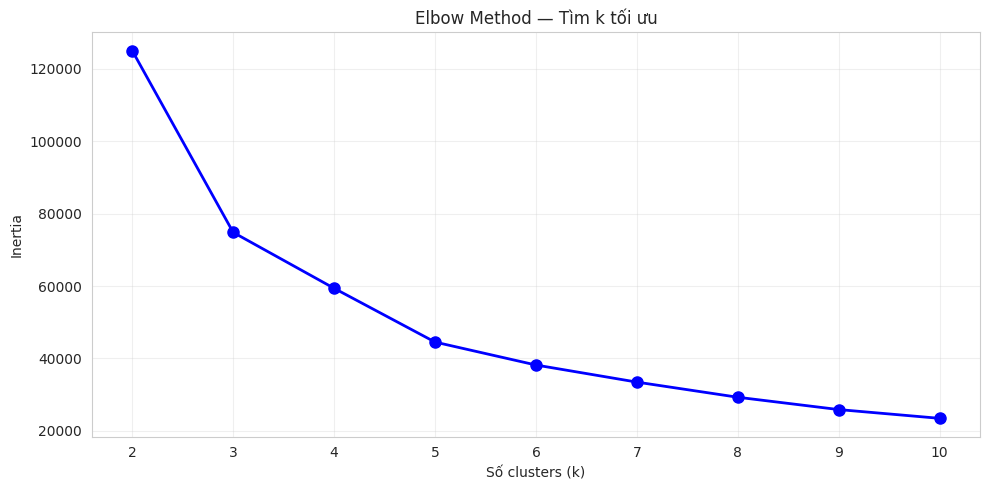

Inertia values:
  k=2: 125,046
  k=3: 74,832
  k=4: 59,380
  k=5: 44,520
  k=6: 38,178
  k=7: 33,454
  k=8: 29,270
  k=9: 25,862
  k=10: 23,440


In [8]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Số clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Tìm k tối ưu')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("Inertia values:")
for k, inertia in zip(k_range, inertias):
    print(f"  k={k}: {inertia:,.0f}")

## K-Means Clustering — Chọn k tối ưu

Dựa vào Elbow Method, ta quan sát mức độ giảm inertia qua từng k:

| k | Inertia | Giảm so với k-1 |
|---|---------|----------------|
| 2 | 125,046 | — |
| 3 | 74,832  | 50,214 |
| 4 | 59,380  | 15,452 |
| 5 | 44,520  | 14,860 |
| 6 | 38,178  | 6,342  |
| 7 | 33,454  | 4,724  |

**Kết luận: Chọn k=4**

Từ k=5 trở đi, mức giảm inertia giảm đột ngột (từ ~15,000 xuống còn ~6,000),
cho thấy việc thêm cluster không mang lại nhiều giá trị phân tách.
k=4 đảm bảo cân bằng giữa độ phức tạp mô hình và khả năng giải thích business.

So sánh với RFM rule-based (6 segments) sẽ được thực hiện ở phần cuối.

Train K-Means k=4

In [9]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Cluster summary
cluster_summary = rfm.groupby('kmeans_cluster').agg(
    count=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(2)
cluster_summary['pct'] = (cluster_summary['count'] / len(rfm) * 100).round(1)

print("=== K-Means Cluster Summary (k=4) ===")
print(cluster_summary.sort_values('avg_monetary', ascending=False))

=== K-Means Cluster Summary (k=4) ===
                count  avg_recency  avg_frequency  avg_monetary   pct
kmeans_cluster                                                       
2                2593       290.30            1.0       1126.09   2.7
0               35532       136.44            1.0        136.49  36.8
1               22573       506.86            1.0        131.96  23.4
3               35780       303.73            1.0        130.64  37.1


Đặt tên cluster theo đặc điểm

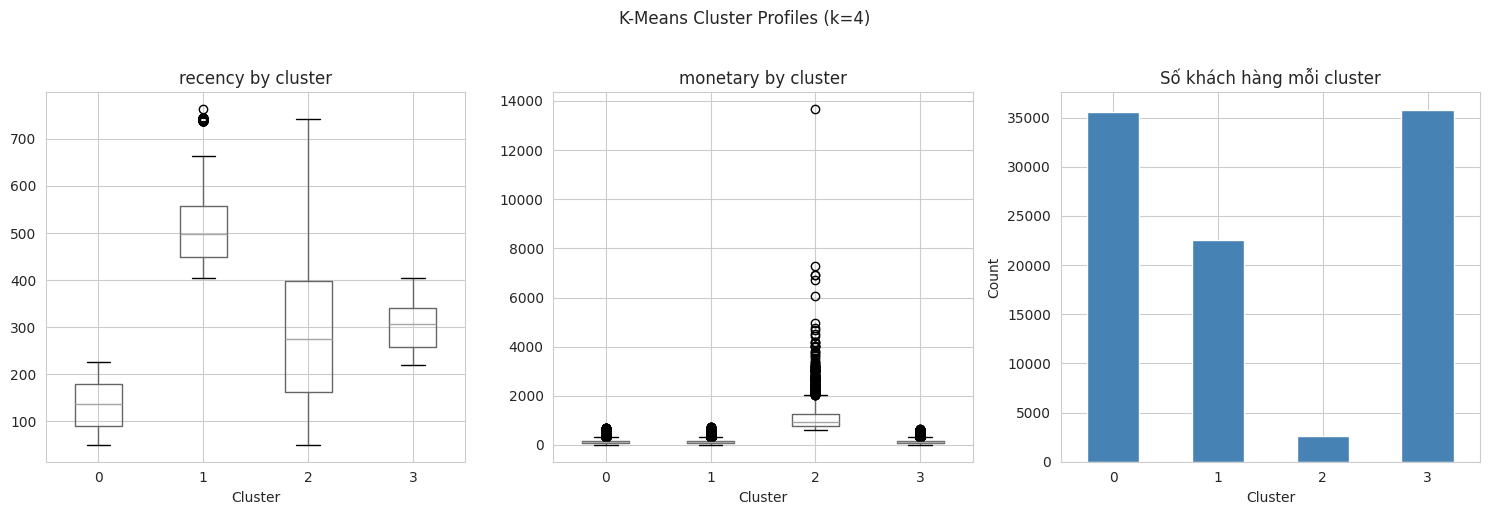

In [10]:
# Visualize cluster profiles
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
features = ['recency', 'monetary', 'avg_monetary']

# Box plot R, M theo cluster
for ax, col in zip(axes, ['recency', 'monetary']):
    rfm.boxplot(column=col, by='kmeans_cluster', ax=ax)
    ax.set_title(f'{col} by cluster')
    ax.set_xlabel('Cluster')

# Bar chart count
cluster_summary['count'].plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Số khách hàng mỗi cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('K-Means Cluster Profiles (k=4)', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

Gán nhãn business cho từng cluster

In [11]:
# Sau khi xem cluster summary, gán nhãn phù hợp
# Logic: recency thấp = mua gần đây, monetary cao = chi nhiều
def label_cluster(row):
    r = row['avg_recency']
    m = row['avg_monetary']

    if r <= 150 and m >= 200:   return 'Champions'
    elif r <= 200:               return 'Promising'
    elif m >= 200:               return 'At Risk — High Value'
    else:                        return 'Lost / Inactive'

cluster_summary['label'] = cluster_summary.apply(label_cluster, axis=1)
print("=== Cluster Labels ===")
print(cluster_summary[['count','pct','avg_recency','avg_monetary','label']])

# Map label về rfm dataframe
label_map = cluster_summary['label'].to_dict()
rfm['kmeans_label'] = rfm['kmeans_cluster'].map(label_map)

=== Cluster Labels ===
                count   pct  avg_recency  avg_monetary                 label
kmeans_cluster                                                              
0               35532  36.8       136.44        136.49             Promising
1               22573  23.4       506.86        131.96       Lost / Inactive
2                2593   2.7       290.30       1126.09  At Risk — High Value
3               35780  37.1       303.73        130.64       Lost / Inactive


In [12]:
# Fix labels dựa trên cluster summary thực tế
def label_cluster(row):
    c = row.name  # cluster index
    if c == 0:   return 'Active Customers'
    elif c == 1: return 'Lost'
    elif c == 2: return 'High Value'
    else:        return 'Inactive'

cluster_summary['label'] = cluster_summary.apply(label_cluster, axis=1)
print("=== Cluster Labels (Fixed) ===")
print(cluster_summary[['count','pct','avg_recency','avg_monetary','label']])

label_map = cluster_summary['label'].to_dict()
rfm['kmeans_label'] = rfm['kmeans_cluster'].map(label_map)
print("\nValue counts:")
print(rfm['kmeans_label'].value_counts())

=== Cluster Labels (Fixed) ===
                count   pct  avg_recency  avg_monetary             label
kmeans_cluster                                                          
0               35532  36.8       136.44        136.49  Active Customers
1               22573  23.4       506.86        131.96              Lost
2                2593   2.7       290.30       1126.09        High Value
3               35780  37.1       303.73        130.64          Inactive

Value counts:
kmeans_label
Inactive            35780
Active Customers    35532
Lost                22573
High Value           2593
Name: count, dtype: int64


## So sánh K-Means vs RFM Rule-based

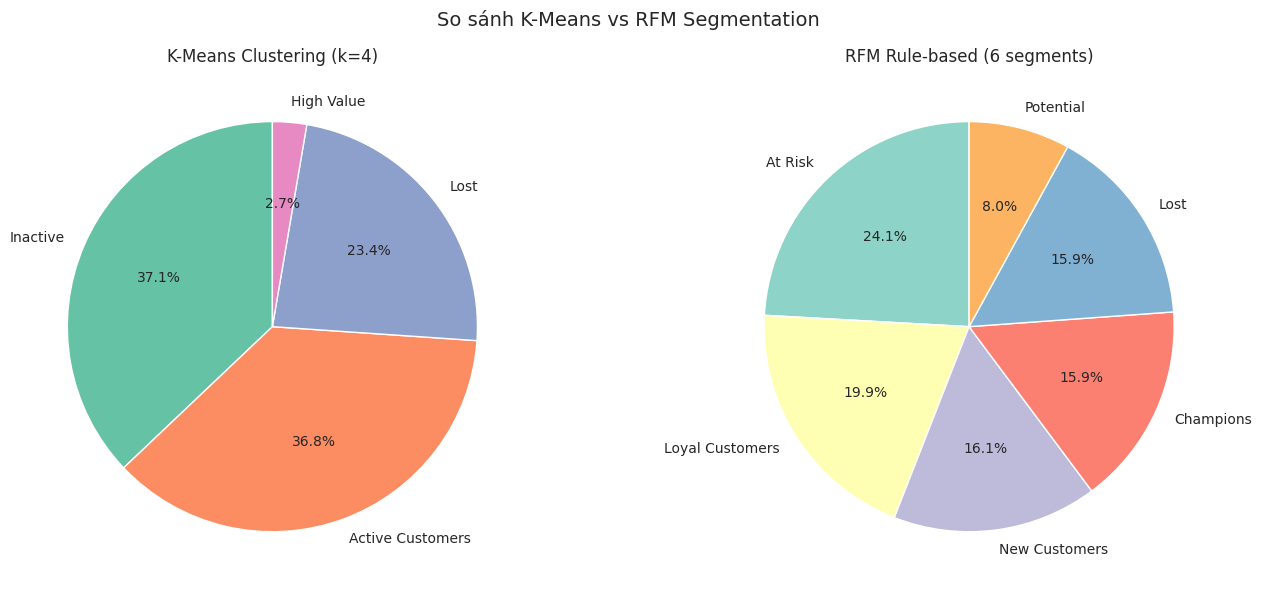

=== K-Means (k=4) ===
                  count   pct
kmeans_label                 
Inactive          35780  37.1
Active Customers  35532  36.8
Lost              22573  23.4
High Value         2593   2.7

=== RFM Rule-based ===
                 count   pct
segment                     
At Risk          23266  24.1
Loyal Customers  19243  19.9
New Customers    15578  16.1
Champions        15378  15.9
Lost             15316  15.9
Potential         7697   8.0


In [14]:
# So sánh phân bổ K-Means vs RFM
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
kmeans_counts = rfm['kmeans_label'].value_counts()
axes[0].pie(kmeans_counts, labels=kmeans_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2'))
axes[0].set_title('K-Means Clustering (k=4)')

# RFM Rule-based
rfm_counts = rfm['segment'].value_counts()
axes[1].pie(rfm_counts, labels=rfm_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set3'))
axes[1].set_title('RFM Rule-based (6 segments)')

plt.suptitle('So sánh K-Means vs RFM Segmentation', fontsize=14)
plt.tight_layout()
plt.savefig('kmeans_vs_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

# Bảng so sánh
print("=== K-Means (k=4) ===")
print(rfm['kmeans_label'].value_counts().to_frame('count')
      .assign(pct=lambda x: (x['count']/len(rfm)*100).round(1)))

print("\n=== RFM Rule-based ===")
print(rfm['segment'].value_counts().to_frame('count')
      .assign(pct=lambda x: (x['count']/len(rfm)*100).round(1)))

## So sánh K-Means vs RFM Rule-based

| | K-Means (k=4) | RFM Rule-based (k=6) |
|--|--------------|---------------------|
| **Phương pháp** | Unsupervised, data-driven | Rule-based, domain knowledge |
| **Số segments** | 4 | 6 |
| **Ưu điểm** | Khách quan, tự động tìm pattern | Dễ giải thích, có business meaning rõ ràng |
| **Nhược điểm** | Khó giải thích cluster | Phụ thuộc vào threshold thủ công |
| **Phát hiện đặc biệt** | Tách được High Value (2.7%) rõ ràng | Phân biệt được Champions vs Loyal |

**Kết luận:** Cả hai phương pháp đều phát hiện ra nhóm khách hàng không hoạt động chiếm khoảng 60% (Inactive + Lost) và nhóm high-value nhỏ (2.7%) có monetary trung bình 1,126 BRL — cao hơn 8x so với các nhóm còn lại (avg 132 BRL).

K-Means phù hợp khi không có domain knowledge, tự động phân tách High Value rõ ràng hơn. RFM phù hợp hơn khi cần giải thích cho business stakeholders vì có label trực quan (Champions, At Risk...).

Trong thực tế, nên kết hợp cả hai: dùng K-Means để discover patterns, sau đó dùng RFM labels để communicate với business.

## Random Forest — Dự đoán Review Score

Chuẩn bị data

In [15]:
# Merge delivery + orders để có đủ features
df_model = delivery.copy()

# Target: high_review = 1 nếu score >= 4, ngược lại = 0
df_model['high_review'] = (df_model['review_score'] >= 4).astype(int)

# Xử lý is_late: TRUE/FALSE → 1/0
df_model['is_late'] = df_model['is_late'].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})

# Features
features = ['delivery_days', 'estimated_days', 'days_diff', 'is_late']
X = df_model[features].dropna()
y = df_model.loc[X.index, 'high_review']

print(f"Dataset: {X.shape[0]:,} samples · {X.shape[1]} features")
print(f"\nTarget distribution:")
print(y.value_counts().to_frame('count')
      .assign(pct=lambda x: (x['count']/len(y)*100).round(1)))
print(f"\nFeatures:\n{X.describe().round(2)}")

Dataset: 96,470 samples · 4 features

Target distribution:
             count   pct
high_review             
1            75637  78.4
0            20833  21.6

Features:
       delivery_days  estimated_days  days_diff   is_late
count       96470.00        96470.00   96470.00  96470.00
mean           12.09           23.37     -11.28      0.08
std             9.55            8.76      10.19      0.26
min             0.00            2.00    -146.00      0.00
25%             6.00           18.00     -16.00      0.00
50%            10.00           23.00     -12.00      0.00
75%            15.00           28.00      -7.00      0.00
max           209.00          155.00     189.00      1.00


Train/Test split & Train model

In [16]:
# Split 80/20 — không shuffle vì không phải time series thuần túy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples")

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\n✅ Model trained!")

Train: 77,176 samples
Test:  19,294 samples

✅ Model trained!


Đánh giá model

=== MODEL EVALUATION ===

Accuracy:  0.8168
F1-Score:  0.8939
ROC-AUC:   0.6628

=== Classification Report ===
                   precision    recall  f1-score   support

 Low Review (1-3)       0.79      0.21      0.33      4167
High Review (4-5)       0.82      0.98      0.89     15127

         accuracy                           0.82     19294
        macro avg       0.80      0.60      0.61     19294
     weighted avg       0.81      0.82      0.77     19294



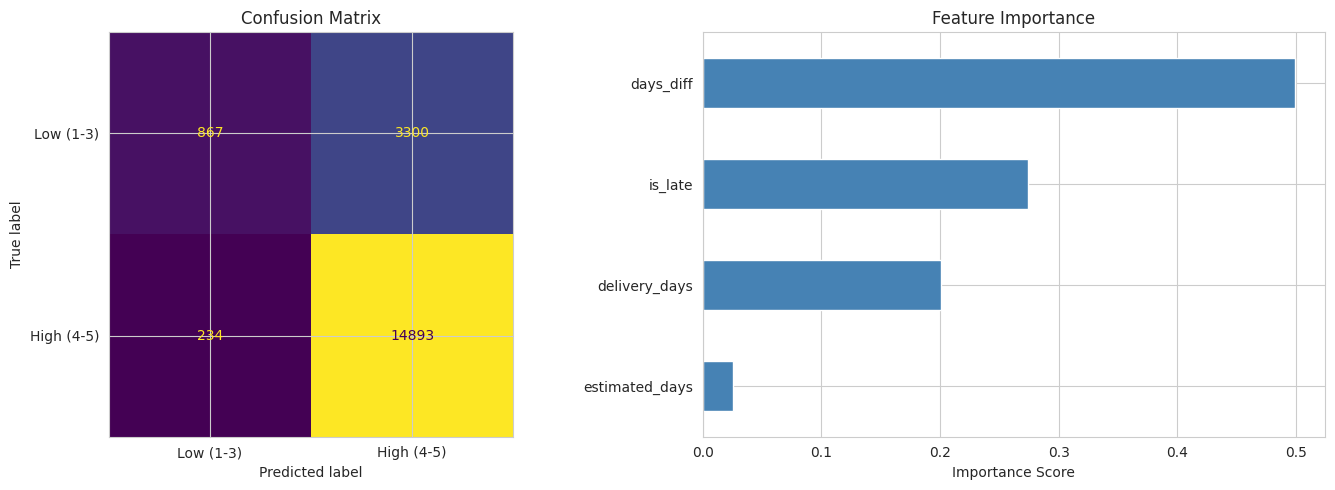

In [17]:
from sklearn.metrics import accuracy_score, f1_score

print("=== MODEL EVALUATION ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Low Review (1-3)', 'High Review (4-5)']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low (1-3)', 'High (4-5)'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('rf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Đánh giá Random Forest

| Metric | Score | Nhận xét |
|--------|-------|---------|
| Accuracy | 81.68% | Tốt — nhưng bị ảnh hưởng bởi class imbalance |
| F1 (High Review) | 0.894 | Model dự đoán tốt class đa số |
| F1 (Low Review) | 0.330 | Yếu — model bỏ sót 79% review thấp |
| ROC-AUC | 0.663 | Trung bình — cần cải thiện |

**Vấn đề: Class Imbalance**
Dataset bị mất cân bằng — High Review (78.5%) vs Low Review (21.5%). Model thiên về dự đoán High Review vì chiếm đa số.

**Feature Importance insight:**
`days_diff` là feature quan trọng nhất (50%) — xác nhận lại finding từ EDA: giao hàng sớm/trễ so với ước tính là yếu tố quyết định nhất đến review score.

**Hướng cải thiện:** Dùng class_weight='balanced' để xử lý imbalance.

In [18]:
# Fix class imbalance bằng class_weight='balanced'
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Fix imbalance
)
rf_balanced.fit(X_train, y_train)
y_pred_b = rf_balanced.predict(X_test)
y_prob_b = rf_balanced.predict_proba(X_test)[:, 1]

print("=== BALANCED MODEL ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_b):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_b):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_b):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_b,
      target_names=['Low Review (1-3)', 'High Review (4-5)']))

=== BALANCED MODEL ===

Accuracy:  0.7622
F1-Score:  0.8512
ROC-AUC:   0.6620

=== Classification Report ===
                   precision    recall  f1-score   support

 Low Review (1-3)       0.44      0.38      0.41      4167
High Review (4-5)       0.84      0.87      0.85     15127

         accuracy                           0.76     19294
        macro avg       0.64      0.62      0.63     19294
     weighted avg       0.75      0.76      0.76     19294



## So sánh Model gốc vs Balanced Model

| Metric | Model gốc | Balanced Model | Thay đổi |
|--------|-----------|----------------|---------|
| Accuracy | 81.68% | 76.22% | -5.46% |
| F1 (High Review) | 0.894 | 0.851 | -0.043 |
| F1 (Low Review) | 0.330 | 0.410 | +0.080 ✅ |
| ROC-AUC | 0.663 | 0.662 | ≈ không đổi |
| Recall (Low) | 0.21 | 0.38 | +0.17 ✅ |

**Nhận xét:**
- Balanced model đánh đổi accuracy tổng thể (-5%) để cải thiện
  khả năng phát hiện review thấp (+17% recall)
- ROC-AUC gần như không đổi (0.663 vs 0.662) — cho thấy
  khả năng phân biệt 2 class của model không thay đổi đáng kể
- **Kết luận:** Nếu business cần phát hiện đơn hàng có nguy cơ
  review thấp để can thiệp kịp thời → dùng Balanced Model.
  Nếu cần accuracy tổng thể cao → dùng Model gốc.

**Tổng kết Feature Importance:**
- `days_diff` (50%) — yếu tố quan trọng nhất: giao sớm hay trễ
  so với ước tính ảnh hưởng mạnh nhất đến review
- `is_late` (28%) — xác nhận finding từ EDA: trễ → review thấp
- `delivery_days` (20%) — thời gian giao hàng thực tế
- `estimated_days` (3%) — ít quan trọng, khách không so sánh
  với estimated nhiều bằng việc có trễ hay không

**Hướng phát triển tiếp theo:**
- Thêm features: payment_value, product_category, customer_state
- Thử XGBoost hoặc LightGBM để cải thiện ROC-AUC
- Dùng SMOTE để oversample class thiểu số thay vì class_weight